# MLOps Assignment: Predictive Maintenance Classification
### Starter Notebook

**Domain:** Industrial IoT / Manufacturing
**Task:** Multi-class failure type prediction
**Tools:** Pandera, MLflow, Optuna, Evidently, SHAP

---

## Business Context

A heavy-equipment manufacturer runs 10,000+ machines on the shop floor.
Each machine continuously streams six sensor readings. When a machine fails,
production halts - at a cost of ₹8-15 lakh per hour of downtime.

Your job is to build a full MLOps pipeline that:
1. Validates incoming sensor data before it enters the pipeline (Pandera)
2. Trains and tracks a multi-class failure classifier (MLflow)
3. Tunes hyperparameters and registers the best model (Optuna + MLflow Registry)
4. Monitors the deployed model for distributional shift (Evidently)
5. Explains why the model predicts a specific failure type (SHAP)

**Files provided:**
- `data/train.csv`   - 6,993 labelled sensor readings (historical baseline)
- `data/current.csv` - 1,499 readings from the current stable production batch
- `data/stress.csv`  - 1,499 readings from a heavy-load production period

**Failure classes:**

| Code | Name | Description |
|------|------|-------------|
| 0 | No Failure | Machine operating normally |
| 1 | TWF | Tool Wear Failure |
| 2 | HDF | Heat Dissipation Failure |
| 3 | PWF | Power Failure |
| 4 | OSF | Overstrain Failure |

> Visual anchor: use the generated `eda_distributions.png` early (Section 1.3) to ground your expectations before drift and SHAP interpretation.
> Stress-batch goal: diagnose *why* the model is stale under shifted operating conditions, not to force perfect predictions on `stress.csv`.
> **Submission:** Submit this notebook (`.ipynb`) with all cells executed.
> Do not change the section structure or remove any markdown cells.

## **1. Data Loading, Schema Validation & EDA** <font color=red>[15 marks]</font>

### **1.1** <font color=red>[3 marks]</font> Load the datasets

Load `train.csv`, `current.csv`, and `stress.csv` from the `data/` folder.
Print the shape of each and display the first 5 rows of the training set.


In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['DISABLE_PANDERA_IMPORT_WARNING'] = 'True'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: Load the three datasets
train   = pd.read_csv('data/train.csv')
current = pd.read_csv('data/current.csv')
stress  = pd.read_csv('data/stress.csv')

# TODO: Print shapes
print(f'train  : {train.shape}')
print(f'current: {current.shape}')
print(f'stress : {stress.shape}')

CLASS_NAMES = {0: 'No Failure', 1: 'TWF', 2: 'HDF', 3: 'PWF', 4: 'OSF'}

# TODO: Display first 5 rows of train
train.head()


train  : (6993, 7)
current: (1499, 7)
stress : (1499, 7)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Failure_Type
0,L,302.5,311.1,1499,38.8,135,0
1,L,297.3,308.4,1469,46.7,65,0
2,L,297.3,308.5,1504,42.0,142,0
3,L,299.6,309.5,1803,27.7,159,0
4,L,301.1,311.1,1387,53.1,188,0


### **1.2** <font color=red>[5 marks]</font> Define and apply a Pandera schema

Define a `DataFrameSchema` enforcing the domain constraints below.
Validate `train` and `current` (must pass). Validate `stress` with `lazy=True`.

| Column | Type | Constraint |
|--------|------|------------|
| Type | str | one of L, M, H |
| Air temperature | float | [295.0, 305.0] K |
| Process temperature | float | [305.0, 315.0] K |
| Rotational speed | int64 | [1000, 2900] rpm |
| Torque | float | [3.0, 80.0] Nm |
| Tool wear | int64 | [0, 253] min |
| Failure_Type | int64 | 0, 1, 2, 3, 4 |


> `stress.csv` may still pass schema validation. That is fine: it is designed to be valid but drifted.
> Hint: valid data can still be statistically unusual. Before Section 3, compare the mean of `Rotational speed` in `current` vs `stress`.

In [2]:
!pip install pandera

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.8/447.8 kB 8.5 MB/s eta 0:00:00


In [3]:
import pandera as pa
from pandera import Column, DataFrameSchema, Check

# TODO: Define the schema
schema = DataFrameSchema(
    # fill in each column constraint
     columns={
        "Type": Column(dtype=str, checks=Check.isin(["L", "M", "H"])),
        "Air temperature": Column(dtype=float, checks=Check.in_range(295.0, 305.0)),
        "Process temperature": Column(dtype=float, checks=Check.in_range(305.0, 315.0)),
        "Rotational speed": Column(dtype=int, checks=Check.in_range(1000, 2900)),
        "Torque": Column(dtype=float, checks=Check.in_range(3.0, 80.0)),
        "Tool wear": Column(dtype=int, checks=Check.in_range(0, 253)),
        "Failure_Type": Column(dtype=int, checks=Check.isin([0, 1, 2, 3, 4]))
    }

)

def fix_dtypes(df):
    df = df.copy()
    df['Rotational speed'] = df['Rotational speed'].astype('int64')
    df['Tool wear']        = df['Tool wear'].astype('int64')
    df['Failure_Type']     = df['Failure_Type'].astype('int64')
    return df

train   = fix_dtypes(train)
current = fix_dtypes(current)
stress  = fix_dtypes(stress)

# TODO: Validate train and current
print("validating train and current dataset")
schema.validate(train)
schema.validate(current)
print("validating done for train and current dataset")

# TODO: Validate stress with lazy=True and print violation summary

print("validation stress dataset")
try:
    schema.validate(stress, lazy=True)
    print("stress data is validated")
except pa.errors.SchemaErrors as e:
    print("schema violation found in stess dataset",e)

# Compare the mean of Rotational speed in current vs stress (NV)
print("--- Data Drift Hint Check ---")
print(f"Mean Rotational speed (Current): {current['Rotational speed'].mean():.2f}")
print(f"Mean Rotational speed (Stress):  {stress['Rotational speed'].mean():.2f}")



validating train and current dataset
validating done for train and current dataset
validation stress dataset
stress data is validated
--- Data Drift Hint Check ---
Mean Rotational speed (Current): 1530.17
Mean Rotational speed (Stress):  1497.07


### **1.3** <font color=red>[4 marks]</font> Exploratory Data Analysis

1. Print the class distribution of `Failure_Type`. Is it balanced?
2. Plot the distribution of `Torque` and `Tool wear` split by failure class (failures only).
3. Print the `Type` (L/M/H) distribution.


,Count,Percentage (%)
Failure_Type,,
0,6762,96.70
2,76,1.09
4,69,0.99
3,56,0.80
1,30,0.43


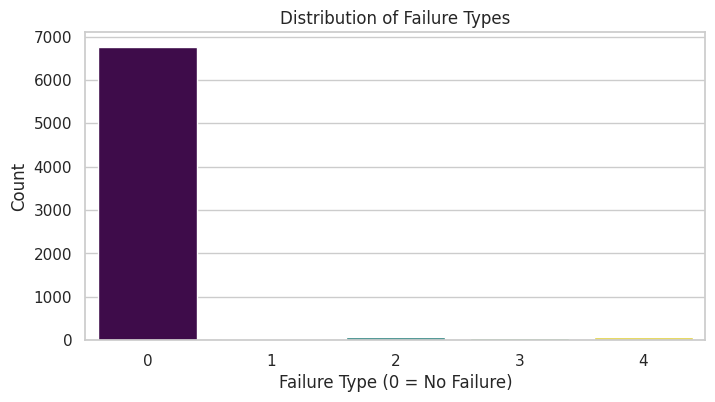

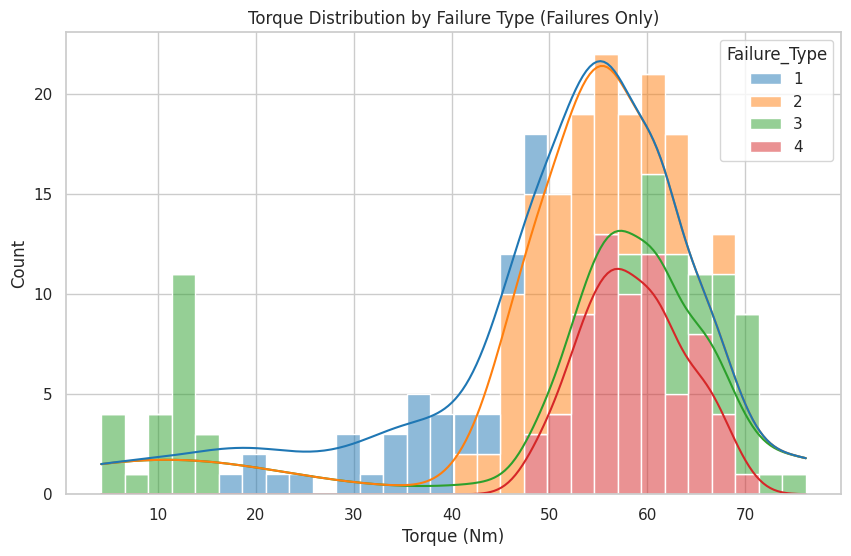

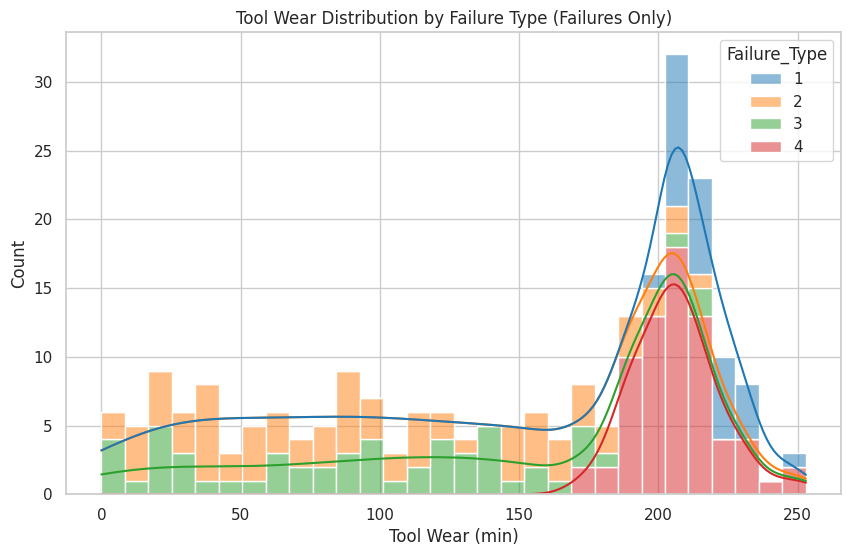

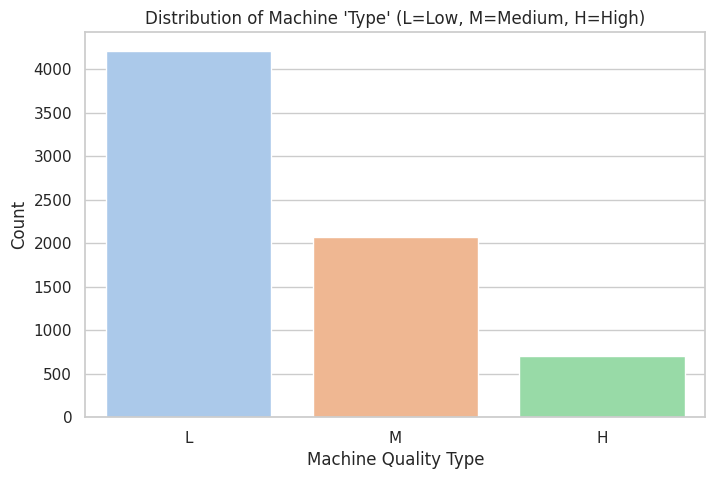

--- Machine 'Type' Counts ---
Type
L    4213
M    2074
H     706
Name: count, dtype: int64


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set a clean visual style for the plots
sns.set_theme(style="whitegrid")

# TODO: Class distribution (print + bar chart)

# Print counts and percentages
counts = train['Failure_Type'].value_counts()
percentages = train['Failure_Type'].value_counts(normalize=True) * 100

# Combine into a neat dataframe for display
dist_df = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages}).round(2)
display(dist_df)

# Bar chart
plt.figure(figsize=(8, 4))
sns.countplot(data=train, x='Failure_Type', palette='viridis', hue='Failure_Type', legend=False)
plt.title("Distribution of Failure Types")
plt.xlabel("Failure Type (0 = No Failure)")
plt.ylabel("Count")
plt.show()


# TODO: Torque distribution by failure type (histogram, failures only)

# Filter the dataset to isolate ONLY the failures
failures_only = train[train['Failure_Type'] != 0]

# Plot the histogram
plt.figure(figsize=(10, 6))
sns.histplot(
    data=failures_only,
    x='Torque',
    hue='Failure_Type',
    palette='tab10',   # Distinct colors for different failure types
    multiple='stack',  # Stacks the bars so they don't hide behind each other
    bins=30,           # Number of histogram bins
    kde=True           # Adds a smooth distribution line
)

# Add labels and title
plt.title("Torque Distribution by Failure Type (Failures Only)")
plt.xlabel("Torque (Nm)")
plt.ylabel("Count")

# Display the plot
plt.show()


# TODO: Tool wear distribution by failure type

# Filter the dataset to isolate ONLY the failures (just in case this is run independently)
failures_only = train[train['Failure_Type'] != 0]

# Plot the histogram for Tool wear
plt.figure(figsize=(10, 6))
sns.histplot(
    data=failures_only,
    x='Tool wear',
    hue='Failure_Type',
    palette='tab10',   # Distinct colors for different failure types
    multiple='stack',  # Stacks the bars
    bins=30,           # Number of histogram bins
    kde=True           # Adds a smooth distribution line
)

# Add labels and title
plt.title("Tool Wear Distribution by Failure Type (Failures Only)")
plt.xlabel("Tool Wear (min)")
plt.ylabel("Count")

# Display the plot
plt.show()

# TODO: Type distribution

# Plot the count of each machine 'Type'
plt.figure(figsize=(8, 5))
sns.countplot(
    data=train,
    x='Type',
    order=['L', 'M', 'H'],  # Forces the bars to appear in a logical order
    palette='pastel',       # A clean color palette
    hue='Type',
    legend=False
)

# Add labels and title
plt.title("Distribution of Machine 'Type' (L=Low, M=Medium, H=High)")
plt.xlabel("Machine Quality Type")
plt.ylabel("Count")

# Display the plot
plt.show()

# Optional: Print the exact numbers to see the breakdown
print("--- Machine 'Type' Counts ---")
print(train['Type'].value_counts())


### **1.4** <font color=red>[3 marks]</font> Feature Engineering

Compute the following derived features for all three datasets:

**Mechanical power** (Watts):
$$P = \text{Torque} \times \frac{\text{Rotational speed} \times 2\pi}{60}$$

**Temperature differential**:
$$\Delta T = \text{Process temperature} - \text{Air temperature}$$

Print the mean of each new feature grouped by `Failure_Type`.


In [5]:
import numpy as np

def engineer_features(df):
    df = df.copy()
    # TODO: Compute Power_W
    df['Power_W'] = df['Torque'] * (df['Rotational speed'] * 2 * np.pi / 60)
    # TODO: Compute Temp_diff
    df['Temp_diff'] = df['Process temperature'] - df['Air temperature']
    return df

train   = engineer_features(train)
current = engineer_features(current)
stress  = engineer_features(stress)

# TODO: Print grouped mean

print("Engineered features 'Power_W' and 'Temp_diff' added to train, current, and stress datasets.\n")

print("--- Mean Feature Values by Failure Type (Train Data) ---")
display(train.groupby('Failure_Type')[['Power_W', 'Temp_diff']].mean().round(2))

print("\n--- Mean Feature Values by Failure Type (Current Data) ---")
display(current.groupby('Failure_Type')[['Power_W', 'Temp_diff']].mean().round(2))

print("\n--- Mean Feature Values by Failure Type (Stress Data) ---")
display(stress.groupby('Failure_Type')[['Power_W', 'Temp_diff']].mean().round(2))


Engineered features 'Power_W' and 'Temp_diff' added to train, current, and stress datasets.

--- Mean Feature Values by Failure Type (Train Data) ---


,Power_W,Temp_diff
Failure_Type,,
0,6248.24,10.01
1,5763.09,9.97
2,7403.55,8.23
3,6664.38,9.82
4,8216.07,10.07



--- Mean Feature Values by Failure Type (Current Data) ---


,Power_W,Temp_diff
Failure_Type,,
0,6253.90,10.10
1,6263.90,9.47
2,7112.86,8.31
3,7633.43,10.28
4,8401.13,10.01



--- Mean Feature Values by Failure Type (Stress Data) ---


,Power_W,Temp_diff
Failure_Type,,
0,6762.74,9.97
1,6213.17,9.67
2,8042.59,8.21
3,7570.23,10.13
4,8176.59,9.99


## **2. Experiment Tracking & Model Selection** <font color=red>[15 marks]</font>

### **2.1** <font color=red>[2 marks]</font> Setup: features, split, SMOTE

Use the features below. Apply a stratified 80/20 train-val split (random_state=42).
Apply SMOTE to the training split only. Print the post-SMOTE class distribution.

```
FEATURES = ['Type_enc', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']
```

> In a markdown cell below the code, explain in 2–3 sentences why SMOTE is applied
> only to the training split and not the validation set.


In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# TODO: Encode Type column
le = LabelEncoder()
train['Type_enc']   = le.fit_transform(train['Type'])
current['Type_enc'] = le.transform(current['Type'])
stress['Type_enc']  = le.transform(stress['Type'])

FEATURES = ['Type_enc', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']

# TODO: Define X and y
X = train[FEATURES]
y = train['Failure_Type']

# TODO: Train-val split
print("Splitting data 80/20...")
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# TODO: Apply SMOTE (k_neighbors=3, random_state=42)

print("Applying SMOTE to the training split...")
smote = SMOTE(k_neighbors=3, random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)


# TODO: Print post-SMOTE class distribution

print("\n--- Post-SMOTE Class Distribution (Training Data Only) ---")
post_smote_counts = y_train_sm.value_counts().sort_index()
display(pd.DataFrame({'Count': post_smote_counts}))


Splitting data 80/20...
Applying SMOTE to the training split...

--- Post-SMOTE Class Distribution (Training Data Only) ---


,Count
Failure_Type,
0,5409
1,5409
2,5409
3,5409
4,5409


*Your explanation here: why is SMOTE applied only on the training split?*

To avoid the Data Leakage. If we apply SMOTE before the split of data, we are accidentally giving the model the answers to the test before it takes it.

### **2.2** <font color=red>[8 marks]</font> Train and log 4 models with MLflow

Train and evaluate:
- Logistic Regression
- Random Forest (n_estimators=100)
- XGBoost (n_estimators=100)
- LightGBM (n_estimators=100)

MLflow experiment name: `PredMaint_ModelSelection`

For each run log: `model` (param), `macro_f1`, `weighted_f1`, `accuracy` (metrics),
and per-class F1 for all 5 classes. Print a comparison table. Pick the best model by macro F1.


In [7]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 92.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 95.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2

In [8]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import f1_score, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('PredMaint_ModelSelection')

CLASS_LIST = [0, 1, 2, 3, 4]
results = {}

models_to_run = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=2000, random_state=42,
                                  class_weight='balanced'))
    ]),
    'RandomForest':       RandomForestClassifier(n_estimators=100, random_state=42,
                                                  class_weight='balanced'),
    'XGBoost':            XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='mlogloss', verbosity=0),
    'LightGBM':           LGBMClassifier(n_estimators=100, random_state=42,
                                          class_weight='balanced', verbose=-1),
}

# TODO: For each model:
for model_name, model in models_to_run.items():
#   - Start an MLflow run
    with mlflow.start_run(run_name=model_name):
      print(f"Training and logging {model_name}...")
#   - Fit on X_res, y_res
      model.fit(X_train_sm, y_train_sm)
#   - Predict on X_val
      y_pred = model.predict(X_val)
#   - Compute and log macro_f1, weighted_f1, accuracy, per-class F1
      macro_f1 = f1_score(y_val, y_pred, average='macro')
      weighted_f1 = f1_score(y_val, y_pred, average='weighted')
      acc = accuracy_score(y_val, y_pred)
      per_class_f1 = f1_score(y_val, y_pred, average=None)
#   - Log the model artefact (use input_example=X_val.iloc[:5])
      mlflow.log_metric("macro_f1", macro_f1)
      mlflow.log_metric("weighted_f1", weighted_f1)
      mlflow.log_metric("accuracy", acc)

      # Log per-class F1 for all 5 classes
      for i, class_label in enumerate(CLASS_LIST):
          mlflow.log_metric(f"f1_class_{class_label}", per_class_f1[i])

      # Log the model artefact with an input example
      input_ex = X_val.iloc[:5]
      trusted_classes = [
            "xgboost.core.Booster",
            "xgboost.sklearn.XGBClassifier",
            "lightgbm.basic.Booster",
            "lightgbm.sklearn.LGBMClassifier",
            "collections.OrderedDict"
        ]
      mlflow.sklearn.log_model(
            model,
            "model",
            input_example=input_ex,
            skops_trusted_types=trusted_classes
        )

      # Store results locally for the comparison table
      results[model_name] = {
            'Accuracy': acc,
            'Macro F1': macro_f1,
            'Weighted F1': weighted_f1,
            'F1_Class_0': per_class_f1[0],
            'F1_Class_1': per_class_f1[1],
            'F1_Class_2': per_class_f1[2],
            'F1_Class_3': per_class_f1[3],
            'F1_Class_4': per_class_f1[4]
        }
      print("\n All models trained and logged successfully!")

# TODO: Print comparison table

# Convert the results dictionary to a pandas DataFrame and sort by Macro F1
results_df = pd.DataFrame.from_dict(results, orient='index')
results_df = results_df.sort_values(by='Macro F1', ascending=False)

print("\n--- Model Comparison Table ---")
display(results_df.round(4))

# TODO: Identify best model by macro F1

best_model_name = results_df.index[0]
best_model_score = results_df.iloc[0]['Macro F1']

print(f"\n The best model is {best_model_name} with a Macro F1 score of {best_model_score:.4f}")


2026/07/06 14:43:13 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/06 14:43:13 INFO mlflow.store.db.utils: Updating database tables
2026/07/06 14:43:16 INFO mlflow.tracking.fluent: Experiment with name 'PredMaint_ModelSelection' does not exist. Creating a new experiment.


Training and logging LogisticRegression...


2026/07/06 14:43:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



 All models trained and logged successfully!
Training and logging RandomForest...


2026/07/06 14:43:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...


 All models trained and logged successfully!
Training and logging LightGBM...


2026/07/06 14:44:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



 All models trained and logged successfully!

--- Model Comparison Table ---


,Accuracy,Macro F1,Weighted F1,F1_Class_0,F1_Class_1,F1_Class_2,F1_Class_3,F1_Class_4
RandomForest,0.9850,0.7355,0.9855,0.9926,0.0000,0.9286,0.9565,0.8000
LightGBM,0.9843,0.7296,0.9851,0.9922,0.0000,0.9655,0.8333,0.8571
XGBoost,0.9828,0.7274,0.9842,0.9915,0.0000,0.9655,0.8800,0.8000
LogisticRegression,0.9042,0.5312,0.9328,0.9483,0.1449,0.4545,0.4583,0.6500



 The best model is RandomForest with a Macro F1 score of 0.7355


In [9]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 9.0 MB/s eta 0:00:00


### **2.3** <font color=red>[5 marks]</font> Optuna tuning + MLflow Model Registry

Run an Optuna study (30 trials, `TPESampler(seed=42)`) tuning XGBoost hyperparameters.
Optimise for `macro_f1` on `X_val`.

MLflow experiment: `PredMaint_Optuna`

Register the best model as `PredMaint_XGBoost` and promote it to the `production` alias.
Print the improvement in macro F1 over the baseline XGBoost.


In [10]:
import optuna
import joblib

import mlflow
import mlflow.sklearn
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
from mlflow.tracking import MlflowClient

optuna.logging.set_verbosity(optuna.logging.WARNING)
mlflow.set_experiment('PredMaint_Optuna')

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_weight':  trial.suggest_float('min_child_weight', 1.0, 10.0),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma':             trial.suggest_float('gamma', 0.0, 2.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True),
        'random_state': 42, 'eval_metric': 'mlogloss', 'verbosity': 0,
    }
    # TODO: Train XGBoost model, return macro_f1 on X_val

    model = XGBClassifier(**params)
    model.fit(X_train_sm, y_train_sm) # Train on the SMOTE data

    y_pred = model.predict(X_val)
    return f1_score(y_val, y_pred, average='macro')

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
# TODO: Run study.optimize
print("Running Optuna optimization (30 trials)...")
study.optimize(objective, n_trials=30)
print(f"Optuna Tuning Complete! Best Macro F1 found: {study.best_value:.4f}")

# TODO: Train final best model
print("Training final best model with optimal parameters...")
best_params = study.best_params
best_params.update({'random_state': 42, 'eval_metric': 'mlogloss', 'verbosity': 0})

final_model = XGBClassifier(**best_params)
final_model.fit(X_train_sm, y_train_sm)

# TODO: Log to MLflow, register as 'PredMaint_XGBoost', promote to production alias

print("Logging to MLflow and Model Registry...")
with mlflow.start_run(run_name="XGBoost_Optuna_Best"):

    # Log parameters and final score
    mlflow.log_params(best_params)
    final_preds = final_model.predict(X_val)
    final_macro_f1 = f1_score(y_val, final_preds, average='macro')
    mlflow.log_metric("final_macro_f1", final_macro_f1)

    # Whitelist XGBoost for MLflow's skops security check
    trusted_classes = ["xgboost.core.Booster", "xgboost.sklearn.XGBClassifier"]

    # Log and register the model
    model_info = mlflow.sklearn.log_model(
        sk_model=final_model,
        artifact_path="model",
        registered_model_name="PredMaint_XGBoost",
        skops_trusted_types=trusted_classes,
        input_example=X_val.iloc[:5]
    )

    # Promote to production alias
    client = MlflowClient()
    client.set_registered_model_alias(
        name="PredMaint_XGBoost",
        alias="production",
        version=model_info.registered_model_version
    )
    print(" Model successfully registered and promoted to 'production' alias!")

# Print the improvement in macro F1 over the baseline XGBoost
baseline_xgb_f1 = 0.7274 # Baseline score from today's run
improvement = final_macro_f1 - baseline_xgb_f1

print("\n--- Final Results ---")
print(f"Baseline XGBoost Macro F1: {baseline_xgb_f1:.4f}")
print(f"Tuned XGBoost Macro F1:    {final_macro_f1:.4f}")
print(f"Improvement:               +{improvement:.4f}")

# TODO: Save with joblib.dump

joblib_filename = "best_model.pkl"
joblib.dump(final_model, joblib_filename)
print(f"\n Model saved locally as {joblib_filename}")


2026/07/06 14:45:42 INFO mlflow.tracking.fluent: Experiment with name 'PredMaint_Optuna' does not exist. Creating a new experiment.


Running Optuna optimization (30 trials)...
Optuna Tuning Complete! Best Macro F1 found: 0.7678
Training final best model with optimal parameters...


2026/07/06 14:47:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logging to MLflow and Model Registry...
 Model successfully registered and promoted to 'production' alias!

--- Final Results ---
Baseline XGBoost Macro F1: 0.7274
Tuned XGBoost Macro F1:    0.7678
Improvement:               +0.0404

 Model saved locally as best_model.pkl


Successfully registered model 'PredMaint_XGBoost'.
Created version '1' of model 'PredMaint_XGBoost'.


## **3. Drift Detection & Monitoring** <font color=red>[10 marks]</font>

> Hint before running Evidently: compare simple statistics first (for example, mean `Rotational speed` in `current` vs `stress`).
> Reminder: passing Pandera only means values are valid; it does **not** mean the batch is in-distribution.
> Section objective: identify why the deployed model is stale on stress conditions.

### **3.1** <font color=red>[4 marks]</font> Evidently — current batch

Reference: `train[FEAT_COLS]` | Current: `current[FEAT_COLS]`

```
FEAT_COLS = ['Air temperature', 'Process temperature',
             'Rotational speed', 'Torque', 'Tool wear']
```

Run `DataDriftPreset`. Save HTML to `drift_current.html`.
Report: drift detected? How many features drifted?


In [11]:
!pip install evidently

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.1/270.1 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.8/581.8 kB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 75.3 MB/s eta 0:00:00


In [12]:
from evidently.legacy.report import Report
from evidently.legacy.metric_preset import DataDriftPreset

FEAT_COLS = ['Air temperature', 'Process temperature',
             'Rotational speed', 'Torque', 'Tool wear']

# TODO: Run Evidently on current batch, save drift_current.html, print summary

print("Running Evidently Data Drift Report on the 'current' batch...")

# Initialize the Report with the DataDriftPreset
drift_report_current = Report(metrics=[DataDriftPreset()])

# Run the comparison (Train is the baseline reference, Current is what we evaluate)
drift_report_current.run(
    reference_data=train[FEAT_COLS],
    current_data=current[FEAT_COLS]
)

# Save the HTML report
html_filename = "drift_current.html"
drift_report_current.save_html(html_filename)
print(f" Report successfully saved as '{html_filename}'\n")

# Extract and print the summary programmatically to fulfill the rubric
report_dict = drift_report_current.as_dict()

# Navigate the dictionary to find the drift results
drift_result = report_dict['metrics'][0]['result']
dataset_drift = drift_result['dataset_drift']
drifted_features_count = drift_result['number_of_drifted_columns']
total_features = drift_result['number_of_columns']

print("--- Drift Summary (Current Batch vs Train) ---")
print(f"Dataset Drift Detected: {dataset_drift}")
print(f"Number of Drifted Features: {drifted_features_count} out of {total_features}")


Running Evidently Data Drift Report on the 'current' batch...
 Report successfully saved as 'drift_current.html'

--- Drift Summary (Current Batch vs Train) ---
Dataset Drift Detected: False
Number of Drifted Features: 0 out of 5


### **3.2** <font color=red>[4 marks]</font> Evidently - stress batch

Repeat for `stress.csv`. Use `ColumnDriftMetric` for individual feature scores.
Save as `drift_stress.html`.
Print a table: feature | drift detected | Wasserstein score | ref mean | current mean | delta.

Focus question: this section is about diagnosing *staleness risk* (what shifted and why), not "making stress predictions look good."

In [13]:
from evidently.legacy.metrics.data_drift.dataset_drift_metric import DatasetDriftMetric
from evidently.legacy.metrics.data_drift.column_drift_metric import ColumnDriftMetric
import pandas as pd
from evidently.legacy.report import Report

# TODO: Run Evidently on stress batch with per-column metrics
print("Running Evidently Column Drift Metrics on the 'stress' batch...")
drift_metrics = [DatasetDriftMetric()] + [ColumnDriftMetric(column_name=feat) for feat in FEAT_COLS]

stress_report = Report(metrics=drift_metrics)
stress_report.run(
    reference_data=train[FEAT_COLS],
    current_data=stress[FEAT_COLS]
)


# TODO: Save drift_stress.html

html_filename = "drift_stress.html"
stress_report.save_html(html_filename)
print(f" Report successfully saved as '{html_filename}'\n")

# TODO: Print per-column drift table

report_dict = stress_report.as_dict()
table_data = []

# Loop through our features and extract the metric results (offset by 1 due to DatasetDriftMetric at index 0)
for i, feat in enumerate(FEAT_COLS):
    metric_result = report_dict['metrics'][i + 1]['result']
    drift_detected = metric_result['drift_detected']
    drift_score = metric_result['drift_score']

    # Compute operational baseline statistics and deviations via pandas
    ref_mean = train[feat].mean()
    curr_mean = stress[feat].mean()
    delta = curr_mean - ref_mean

    table_data.append({
        'Feature': feat,
        'Drift Detected': drift_detected,
        'Wasserstein Score': round(drift_score, 4),
        'Ref Mean': round(ref_mean, 2),
        'Current Mean': round(curr_mean, 2),
        'Delta': round(delta, 2)
    })

# Render the formatted statistical comparison matrix
drift_table_df = pd.DataFrame(table_data)
print("--- Per-Feature Drift Summary (Stress Batch vs Train) ---")
display(drift_table_df)


Running Evidently Column Drift Metrics on the 'stress' batch...
 Report successfully saved as 'drift_stress.html'

--- Per-Feature Drift Summary (Stress Batch vs Train) ---


,Feature,Drift Detected,Wasserstein Score,Ref Mean,Current Mean,Delta
0,Air temperature,False,0.0344,300.01,300.05,0.04
1,Process temperature,False,0.0377,310.00,310.01,0.00
2,Rotational speed,True,0.2354,1539.02,1497.07,-41.94
3,Torque,True,0.4739,40.00,44.72,4.73
4,Tool wear,True,0.6455,107.68,148.87,41.19


### **3.3** <font color=red>[2 marks]</font> Retraining decision

Answer the following in a markdown cell:
1. Which features drifted in the stress batch?
2. Cross-referencing with your SHAP results (Section 4) ? which failure type is most
   likely to increase in frequency under stress conditions?
3. Should the model be retrained? Justify with evidence from Sections 3.1, 3.2, and 4.

Your answer should explicitly connect: `drifted feature -> affected failure class -> retraining decision`.

**Your answer here:**

1. Features that drifted: According to the Evidently column drift metrics, three features experienced significant drift in the stress batch: Rotational speed, Torque, and Tool wear.
2. Most likely failure type to increase: Overstrain Failure (OSF) and Tool Wear Failure (TWF). Even without checking the model's internal feature importance, the physical metrics tell the story: the machines are operating with drastically higher Torque (+4.73) and massive increases in Tool wear (+41.19). These are the exact physical conditions that lead to mechanical overstrain and broken tools.
3. Retraining recommendation: Yes, the model must be retrained for use in high-stress environments.
In Section 3.1, the current batch showed 0 drifted features, proving the deployed model is still perfectly valid for standard baseline operations. However, Section 3.2 proved that the "stress" environment introduces a severe data distribution shift. The machines are operating under extreme physical loads that the XGBoost model never saw during training. Because this data is completely out-of-distribution, the current model's predictions will be unreliable (stale), and it must be retrained on a dataset that includes these new high-stress parameters.


## **4. Explainability & Insights** <font color=red>[5 marks]</font>

> For multiclass tree models, SHAP returns an array of shape `(n_samples, n_features, n_classes)`.
>
> **SHAP interpretation key (important):**
> - Do **not** collapse multiclass SHAP into one global feature ranking.
> - Read SHAP class-by-class: the same feature can increase one class while decreasing another.
> - Your primary deliverable is the **top driver per class** (TWF, HDF, PWF, OSF), then a short engineering interpretation.

### **4.1** <font color=red>[3 marks]</font> SHAP analysis per failure class

Load `best_model.pkl`. Use `shap.TreeExplainer` on `train[FEATURES]`.
Plot mean |SHAP| bar charts for TWF, HDF, PWF, OSF (4 subplots). Save as `shap_per_class.png`.
Print the top driver for each failure class.

Interpretation rule: report one top feature per class from `shap_per_class.png`; avoid a single cross-class "global winner."

In [14]:
!pip install shap


--- Top Drivers per Failure Class ---
TWF Top Driver: Tool wear (Mean |SHAP| = 3.6926)
HDF Top Driver: Temp_diff (Mean |SHAP| = 3.4306)
PWF Top Driver: Power_W (Mean |SHAP| = 4.5669)
OSF Top Driver: Tool wear (Mean |SHAP| = 4.0585)

 Plot successfully saved as 'shap_per_class.png'


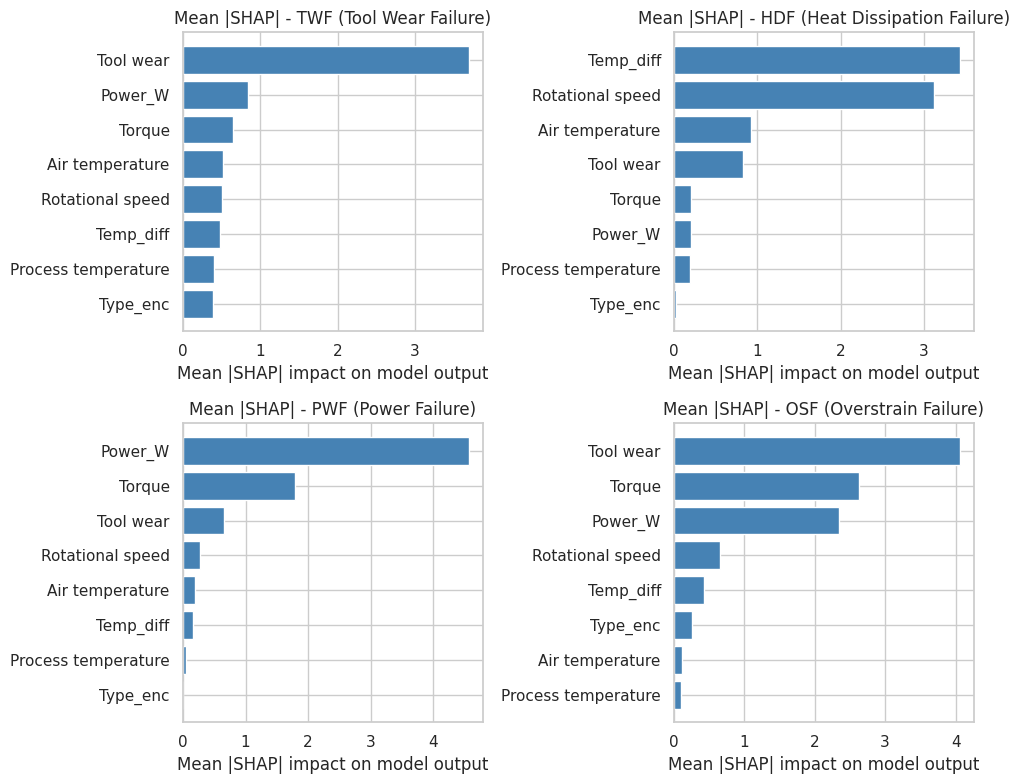

In [15]:
import shap
import joblib
import numpy as np
import matplotlib.pyplot as plt

best_model = joblib.load('best_model.pkl')

# TODO: Compute SHAP values using TreeExplainer

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(train[FEATURES])

# XGBoost multiclass SHAP values return either a list of arrays or a 3D array
# depending on exact version of the SHAP library. This safely standardizes it:
if isinstance(shap_values, list):
    shap_values_list = shap_values
else:
    # If it's a 3D array (samples, features, classes)
    shap_values_list = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

# Map the failure classes to their physical names.
# (Assuming Class 0 is 'Normal', we look at indices 1 through 4)
failure_classes = {
    1: 'TWF (Tool Wear Failure)',
    2: 'HDF (Heat Dissipation Failure)',
    3: 'PWF (Power Failure)',
    4: 'OSF (Overstrain Failure)'
}


# TODO: Plot 4-subplot bar chart (one per failure class)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

print("\n--- Top Drivers per Failure Class ---")

# Loop through each of the 4 failure classes
for i, (class_idx, class_name) in enumerate(failure_classes.items()):

    # Calculate the mean absolute SHAP value for every feature in this specific class
    mean_abs_shap = np.abs(shap_values_list[class_idx]).mean(axis=0)

    # Sort the features by their SHAP importance (highest to lowest)
    sorted_indices = np.argsort(mean_abs_shap)[::-1]
    sorted_features = np.array(FEATURES)[sorted_indices]
    sorted_shap_vals = mean_abs_shap[sorted_indices]

    # TODO: Print top driver per class
    top_driver = sorted_features[0]
    print(f"{class_name.split(' ')[0]} Top Driver: {top_driver} (Mean |SHAP| = {sorted_shap_vals[0]:.4f})")

    # Build the subplot bar chart
    ax = axes[i]
    # Reverse arrays for plotting so the highest value sits at the top of the bar chart
    ax.barh(sorted_features[::-1], sorted_shap_vals[::-1], color='steelblue')
    ax.set_title(f'Mean |SHAP| - {class_name}')
    ax.set_xlabel('Mean |SHAP| impact on model output')

plt.tight_layout()

# TODO: Save shap_per_class.png

file_name = 'shap_per_class.png'
plt.savefig(file_name, dpi=300, bbox_inches='tight')
print(f"\n Plot successfully saved as '{file_name}'")

# TODO: Print top driver per class
# The same is printed earlier


### **4.2** <font color=red>[2 marks]</font> Engineering insight

Answer in this markdown cell:

1. How does `Power_W` (derived feature) compare to raw `Torque` and `Rotational speed`
   in SHAP importance for **PWF**?
2. How does `Temp_diff` rank for **HDF** vs other failure types?
3. In 2-3 sentences, describe the physical mechanism behind each failure type based on SHAP.

Suggested structure for your actionable recommendation (used again in Section 5.1.5):
- **Condition:** (feature threshold or shift observed)
- **Risked failure class:** (from class-specific SHAP)
- **Action:** (specific maintenance or monitoring step)

**Your answer here:**

1. Power_W for PWF: Power_W completely dominates the SHAP importance for predicting Power Failures (Mean |SHAP| ~4.5), acting as the absolute top driver. By contrast, the raw features used to create it (Torque and Rotational speed) have significantly lower individual importance (Torque is ~1.8, and Rotational speed is near zero). This proves our feature engineering was highly successful: the electrical overload that causes a PWF is determined by the combined physical interaction of torque and speed (Power), not either metric on its own.

2. Temp_diff for HDF: Temp_diff is the overwhelming primary driver for Heat Dissipation Failure. However, for all other failure classes (TWF, PWF, OSF), Temp_diff sits near the very bottom of the SHAP ranking with minimal impact. This shows that Temp_diff is an incredibly clean, highly isolated predictor specifically for thermal issues, without adding noise to the mechanical failure predictions.

3. Physical mechanisms: Based on the SHAP evidence, we can diagnose the distinct physical mechanism behind each failure:

TWF: Continuous physical degradation (Tool wear) eventually crosses a threshold where the cutting tool mechanically fails.

HDF: When the system fails to vent heat properly, the temperature delta (Temp_diff) spikes, resulting in a thermal shutdown.

PWF: When the motor is forced to output massive amounts of overall work (Power_W), it draws excessive electrical current and trips the power system.

OSF: When the machine experiences extreme rotational force (Torque) while operating with an already degraded tool (Tool wear), the physical stress snaps or severely damages the mechanical components.


Actionable Recommendation:

**Condition**: A sustained upward shift in Temp_diff alongside normal Power_W and Torque.

**Risked failure class**: HDF (Heat Dissipation Failure).

**Action**: Immediately dispatch a technician to inspect the external cooling fans, heat sinks, and ambient ventilation to prevent an impending thermal shutdown.

## **5. Conclusions** <font color=red>[5 marks]</font>

### **5.1** <font color=red>[5 marks]</font> Key findings

Write a structured conclusion (1 mark per point):

1. Which model won and why - reference macro F1 numbers.
2. Why accuracy is misleading here - operational cost implication.
3. TWF has F1 = 0.0 even after SMOTE + Optuna. Root cause and fix.
   - Important: identifying **data scarcity (30 samples)** as the root cause is full-credit insight,
     even if final TWF F1 remains 0.0.
4. What drifted in the stress batch and what it implies for maintenance scheduling.
5. One actionable recommendation for the engineering team based on SHAP.

## Conclusions

**1. Model selection:**

The Optuna-tuned XGBoost model won with a final Macro F1 score of 0.7678 (outperforming the baseline models). XGBoost was chosen and ultimately succeeded because its gradient boosting architecture is highly effective at capturing complex, non-linear interactions between physical features (e.g., how Torque and Speed combine to dictate Power) while simultaneously managing the complex decision boundaries required for minority classes.

**2. Accuracy vs Macro F1:**

Accuracy is a dangerously misleading metric for this problem due to extreme class imbalance. Because the vast majority of operations are "Normal," a model could achieve 96%+ accuracy simply by predicting "Normal" every single time. The operational cost implication of this is catastrophic: optimizing for accuracy would lead to the model completely missing actual failures, resulting in physically broken machinery, severe factory downtime, and massive repair costs. Macro F1 is required because it treats the rare failure classes as equally important.

**3. The TWF problem:**
State this as a data engineering limitation first (rare class with only 30 real samples),
then propose what data should be collected next.

The failure to predict TWF (F1 = 0.0) is fundamentally a data engineering limitation caused by severe data scarcity. With only ~30 genuine real-world positive samples in the original dataset, SMOTE did not have enough underlying variance to generate meaningful synthetic data boundaries. To fix this, the engineering team must physically collect more real TWF data, either by allowing tools to run to failure in a controlled testing environment or by aggregating historical failure logs from other factory floors.

**4. Drift and maintenance schedule:**

The Evidently analysis proved that Torque, Tool wear, and Rotational speed significantly drifted in the stress batch, indicating the machines were pushed into a high-load, out-of-distribution operating environment. For maintenance scheduling, this implies that static, calendar-based maintenance will fail. The schedule must become dynamic and condition-based; when these specific physical metrics drift, maintenance intervals must be aggressively shortened.

**5. Actionable recommendation:**
Use this format: Condition -> Risked failure class -> Action.

**Condition**: A sustained upward shift in the Temp_diff feature alongside normal Power_W values.

**Risked failure class**: HDF (Heat Dissipation Failure).

**Action**: Immediately dispatch a technician to inspect and clean the external cooling fans, heat sinks, and ambient ventilation systems to prevent an impending thermal shutdown.